<a href="https://colab.research.google.com/github/mishrasubhajit/genreclassification/blob/main/Netflix_movie_genre_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1️⃣ Data Exploraton:


In this section, we want to see your ability to explore a dataset from scratch. You will be asked a series of questions whose answer is hidden within a dataset. After each question, you can write some code using Colab cells so that we can see how you arrived at the answer. Try to answer each question correctly, but in case you can't, we recommend that you go ahead and finish the test.


**Tip**: We really appreciate data visualization and storytelling, so surprise us and show us what interesting information you can extract from the dataset using visualizations 📊 📈  




You have a dataset of movies found on the Netflix Streaming Platform. The structure of the dataset is as follows :
- show_id : identifier of each data point
- type : problem type
- title : movie title
- director : director of the movie
- cast : the actors who starred in that movie
- country : where the movie was shot
- date_added : date on which this data point was recorded in the dataset
- release_year : date on which this film was released
- duration : film duration
- description : movie plot description
- genre : movie genre

## Load the dataset

In [ ]:
!pip install networkx

import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sentence_transformers import SentenceTransformer

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
#start your code here!
df = pd.read_csv('/content/drive/MyDrive/Pi School of AI/Coding Test/pi_school_dataset/train.csv').drop(["Unnamed: 0"], axis=1)
df_test = pd.read_csv('/content/drive/MyDrive/Pi School of AI/Coding Test/pi_school_dataset/test.csv').drop(["Unnamed: 0"], axis=1)

df_org = df.copy()
df_test_org = df_test.copy()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6223 entries, 0 to 6222
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       6223 non-null   object
 1   type          6223 non-null   object
 2   title         6223 non-null   object
 3   director      4330 non-null   object
 4   cast          5654 non-null   object
 5   country       5800 non-null   object
 6   date_added    6216 non-null   object
 7   release_year  6223 non-null   int64 
 8   duration      6223 non-null   int64 
 9   description   6223 non-null   object
 10  genre         6223 non-null   object
dtypes: int64(2), object(9)
memory usage: 534.9+ KB


In [ ]:
df.describe()

,release_year,duration
count,6223.000000,6223.000000
mean,2013.928652,69.130162
std,8.707360,50.968708
min,1925.000000,1.000000
25%,2013.000000,2.000000
50%,2017.000000,88.000000
75%,2018.000000,106.000000
max,2021.000000,312.000000


In [ ]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,1893
cast,569
country,423
date_added,7
release_year,0
duration,0
description,0


In [ ]:
df_test.isnull().sum()

,0
show_id,0
type,0
title,0
director,492
cast,149
country,84
date_added,3
release_year,0
duration,0
description,0


In [ ]:
df['director_isnull'] = df['director'].isnull()
df['cast_isnull'] = df['cast'].isnull()
df['date_added_isnull'] = df['date_added'].isnull()
df['country_isnull'] = df['country'].isnull()

In [ ]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,duration,description,genre,director_isnull,cast_isnull,date_added_isnull,country_isnull
0,s6129,TV Show,The Big Family Cooking Showdown,NaN,"Zoe Ball, Nadiya Hussain, Giorgio Locatelli, R...",United Kingdom,"February 22, 2019",2018,2,"In this unscripted series, families passionate...",British TV,True,False,False,False
1,s7019,TV Show,The World's Most Extraordinary Homes,NaN,"Piers Taylor, Caroline Quentin",United Kingdom,"January 18, 2019",2019,3,Award-winning architect Piers Taylor and actre...,British TV,True,False,False,False
2,s4658,TV Show,One-Punch Man,NaN,"Makoto Furukawa, Kaito Ishikawa, Yuki Kaji, Ao...",Japan,"March 20, 2017",2015,1,The most powerful superhero in the world can k...,Anime Series,True,False,False,False
3,s6168,Movie,The Boy Who Harnessed the Wind,Chiwetel Ejiofor,"Maxwell Simba, Chiwetel Ejiofor, Aïssa Maïga, ...",United Kingdom,"March 1, 2019",2019,114,"Inspired by a science book, 13-year-old Willia...",Children,False,False,False,False
4,s3563,Movie,"LeapFrog: Sing-along, Read-along",Ron Myrick,"Julie Maddalena, Cindy Robinson",NaN,"April 15, 2020",2011,32,"Using rhythm and rhymes, a funky band and a co...",Children,False,False,False,True


<Axes: xlabel='type', ylabel='count'>

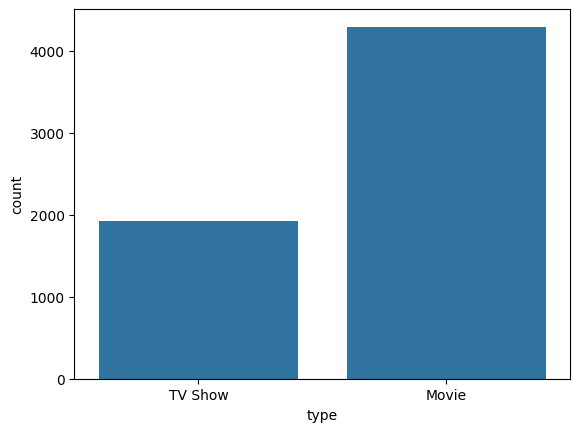

In [ ]:
sns.countplot(data=df, x='type')

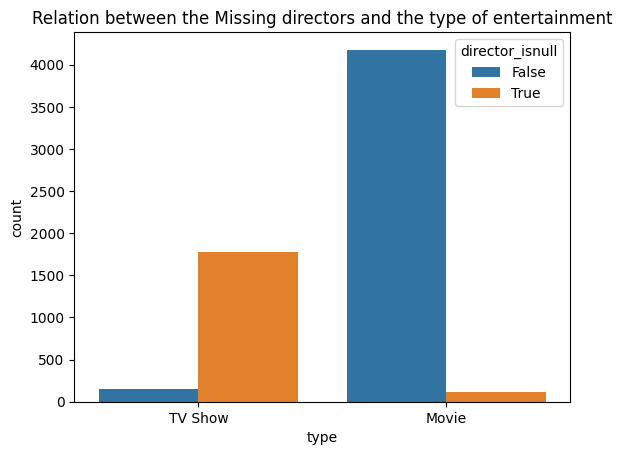

In [ ]:
sns.countplot(data=df, x='type', hue='director_isnull')
plt.title('Relation between the Missing directors and the type of entertainment')
plt.show()

In [ ]:
df.loc[(df['director_isnull'] == False) & (df['type'] == 'TV Show')].shape

(152, 15)

In [ ]:
print(df.loc[(df['director_isnull'] == True) & (df['date_added_isnull'] == True)].shape)
print(df.loc[(df['director_isnull'] == True) & (df['date_added_isnull'] == True) & (df['cast_isnull'] == True)].shape)

(7, 15)
(0, 15)


In [ ]:
df.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,duration,description,genre,director_isnull,cast_isnull,date_added_isnull,country_isnull
0,s6129,TV Show,The Big Family Cooking Showdown,NaN,"Zoe Ball, Nadiya Hussain, Giorgio Locatelli, R...",United Kingdom,"February 22, 2019",2018,2,"In this unscripted series, families passionate...",British TV,True,False,False,False
1,s7019,TV Show,The World's Most Extraordinary Homes,NaN,"Piers Taylor, Caroline Quentin",United Kingdom,"January 18, 2019",2019,3,Award-winning architect Piers Taylor and actre...,British TV,True,False,False,False


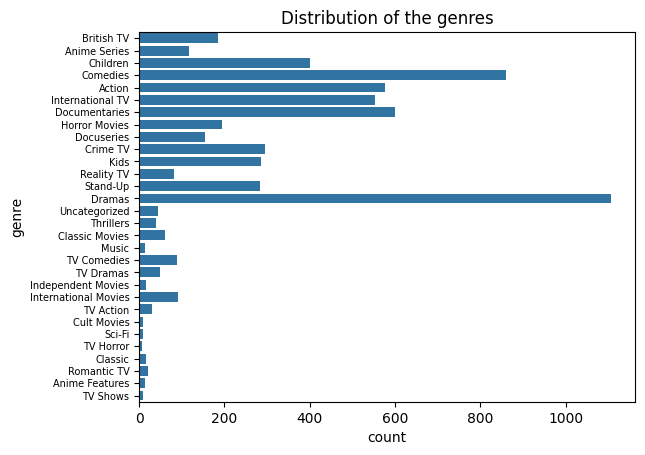

In [ ]:
sns.countplot(data=df, y='genre')
plt.yticks(fontsize=7)
plt.title('Distribution of the genres')
plt.show()


### Handling Missing Values and Parsing `date_added`

In [ ]:
df = df_org.copy()
df = df.drop(['show_id'], axis=1)
df['director'] = df['director'].fillna('_Missing_')
df['cast'] = df['cast'].fillna('_Missing_')
df['country'] = df['country'].fillna('_Missing_')
df['date_added'] = df['date_added'].fillna('_Missing_') # has been handled later
df.head(4)

,type,title,director,cast,country,date_added,release_year,duration,description,genre
0,TV Show,The Big Family Cooking Showdown,_Missing_,"Zoe Ball, Nadiya Hussain, Giorgio Locatelli, R...",United Kingdom,"February 22, 2019",2018,2,"In this unscripted series, families passionate...",British TV
1,TV Show,The World's Most Extraordinary Homes,_Missing_,"Piers Taylor, Caroline Quentin",United Kingdom,"January 18, 2019",2019,3,Award-winning architect Piers Taylor and actre...,British TV
2,TV Show,One-Punch Man,_Missing_,"Makoto Furukawa, Kaito Ishikawa, Yuki Kaji, Ao...",Japan,"March 20, 2017",2015,1,The most powerful superhero in the world can k...,Anime Series
3,Movie,The Boy Who Harnessed the Wind,Chiwetel Ejiofor,"Maxwell Simba, Chiwetel Ejiofor, Aïssa Maïga, ...",United Kingdom,"March 1, 2019",2019,114,"Inspired by a science book, 13-year-old Willia...",Children


In [ ]:
# parsing date-time
df["date_added_parsed"] = pd.to_datetime(
    df["date_added"].replace("_Missing_", pd.NA), # this step could have been avoided.
    errors="coerce"
)

# year and month
df["year_added"] = df["date_added_parsed"].dt.year
df["month_added"] = df["date_added_parsed"].dt.month

# Handle missing parsed dates
df["year_added"] = df["year_added"].fillna(df["year_added"].median()).astype(int)
df["month_added"] = df["month_added"].fillna(0).astype(int)  # 0 = _Missing_

# Difference between release and addition to database of Netflix
df["lag_years"] = df["year_added"] - df["release_year"] # this may be important for old classic movies



### Correlation between numerical variables.

From the correlation matrix plot we see that none of the variables are highly correlated.

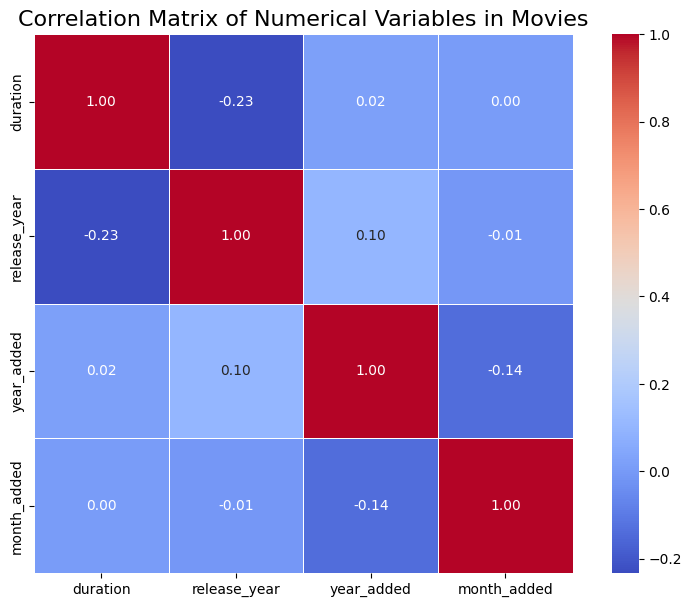

In [ ]:
# Explore correlations between numeric variables using seaborn's `heatmap`
correlation_matrix = df[['duration', 'release_year', 'year_added', 'month_added']].corr()
plt.figure(figsize=(10, 7))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True, square=True, linewidths=0.5)
plt.title('Correlation Matrix of Numerical Variables in Movies', fontsize=16)
plt.show()

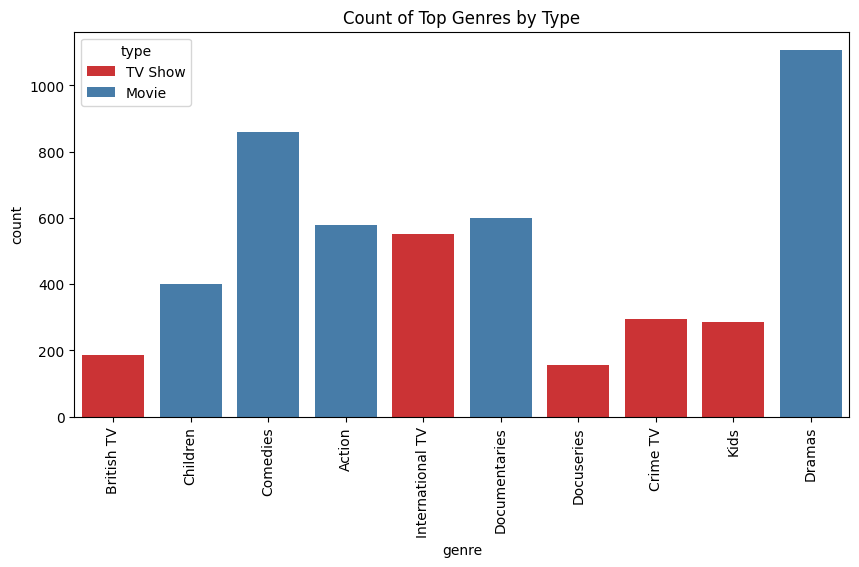

In [ ]:
# Top genres for each type
top_genres_movie = df[df['type'] == 'Movie']['genre'].value_counts().head(5).index
top_genres_tv = df[df['type'] == 'TV Show']['genre'].value_counts().head(5).index
top_genres = set(top_genres_movie) | set(top_genres_tv)


filtered_data = df[df['genre'].isin(top_genres)]

# Create grouped bar plot
plt.figure(figsize=(10, 5))
sns.countplot(data=filtered_data, x='genre', hue='type', palette='Set1')
plt.title('Count of Top Genres by Type')
plt.xticks(rotation=90)
plt.show()

In [ ]:
#cross-tabulation
ct = pd.crosstab(df['type'], df['genre'])

# Transpose the table for better readability
ct_transposed = ct.T

# Display the table
print(ct_transposed)

type                  Movie  TV Show
genre                               
Action                  577        0
Anime Features           15        0
Anime Series              0      118
British TV                0      185
Children                401        0
Classic                   0       17
Classic Movies           62        0
Comedies                859        0
Crime TV                  0      295
Cult Movies              10        0
Documentaries           601        0
Docuseries                0      155
Dramas                 1107        0
Horror Movies           195        0
Independent Movies       16        0
International Movies     91        0
International TV          0      552
Kids                      0      287
Music                    14        0
Reality TV                0       82
Romantic TV               0       22
Sci-Fi                    9        0
Stand-Up                256       27
TV Action                 0       30
TV Comedies               0       88
T

### 0.   Are the variables in the dataset related? If yes what does it mean?

**Answer** (in 2 sentences): Even though the numerical values don't seem to be related, there is a relation between type and genre, some genres appear to be present more than the other. We also see that most of the missing directors are for the TV Shows, which may suggesh multiple directors per season.

In [ ]:
#start your code here!

### 1.   Do the features in this dataset contain outliers?

There are outliers in `release_year` and `duration`. The outliers have been detected using the Inter Quantile Range method using `boxplot`/`violinplot` of `seaborn`.

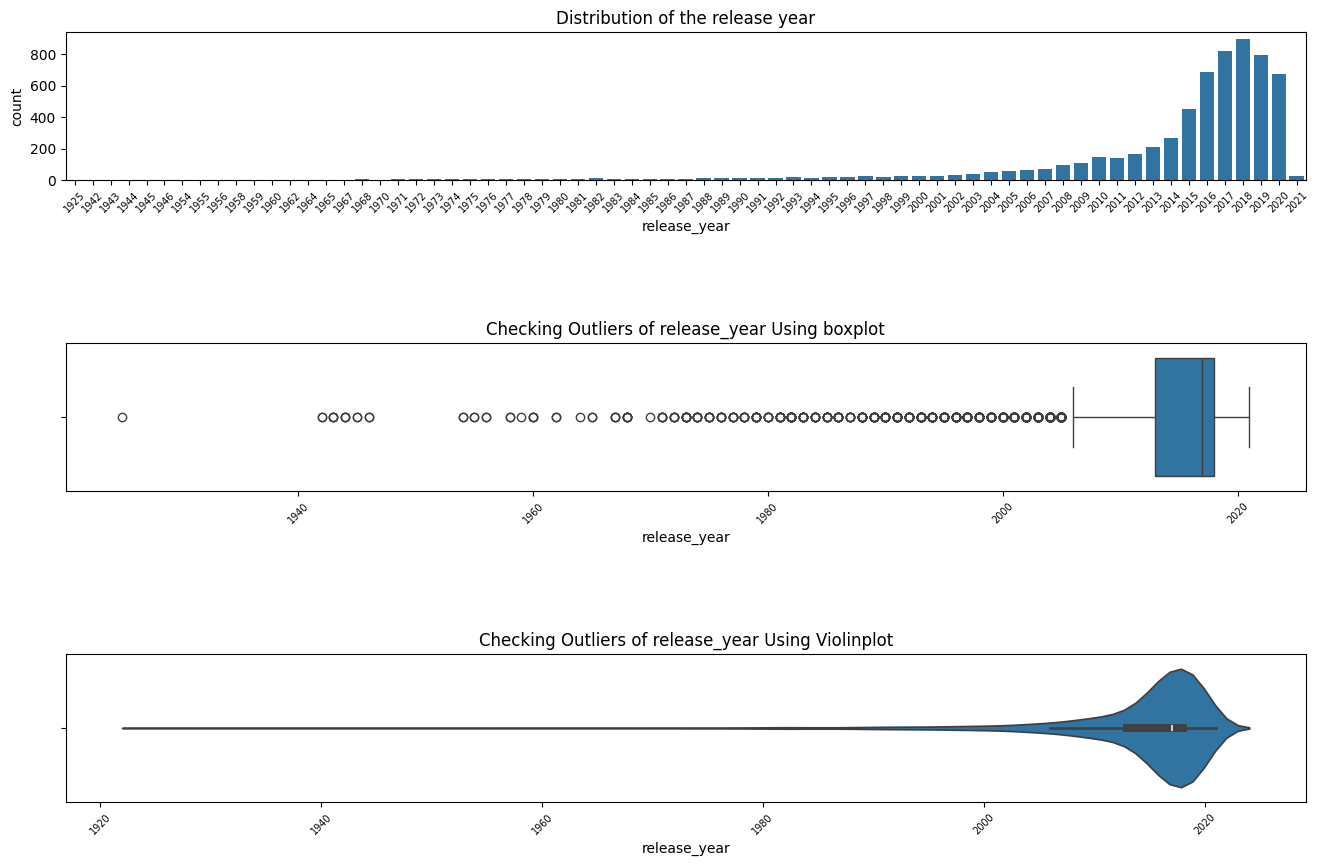

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(16, 10))
sns.countplot(data=df, x='release_year', ax=axes[0])
sns.boxplot(data=df, x='release_year', ax=axes[1])
sns.violinplot(data=df, x='release_year', ax=axes[2])

axes[0].set_title('Distribution of the release year')
axes[1].set_title('Checking Outliers of release_year Using boxplot')
axes[2].set_title('Checking Outliers of release_year Using Violinplot')

for ax in axes:
    ax.tick_params(axis='x', rotation=45, labelsize=7)

# axes[0].tick_params(axis='x', rotation=45, labelsize=7)
# axes[1].tick_params(axis='x', rotation=45, labelsize=7)
# axes[2].tick_params(axis='x', rotation=45, labelsize=7)

plt.subplots_adjust(hspace=1.1)
plt.show()

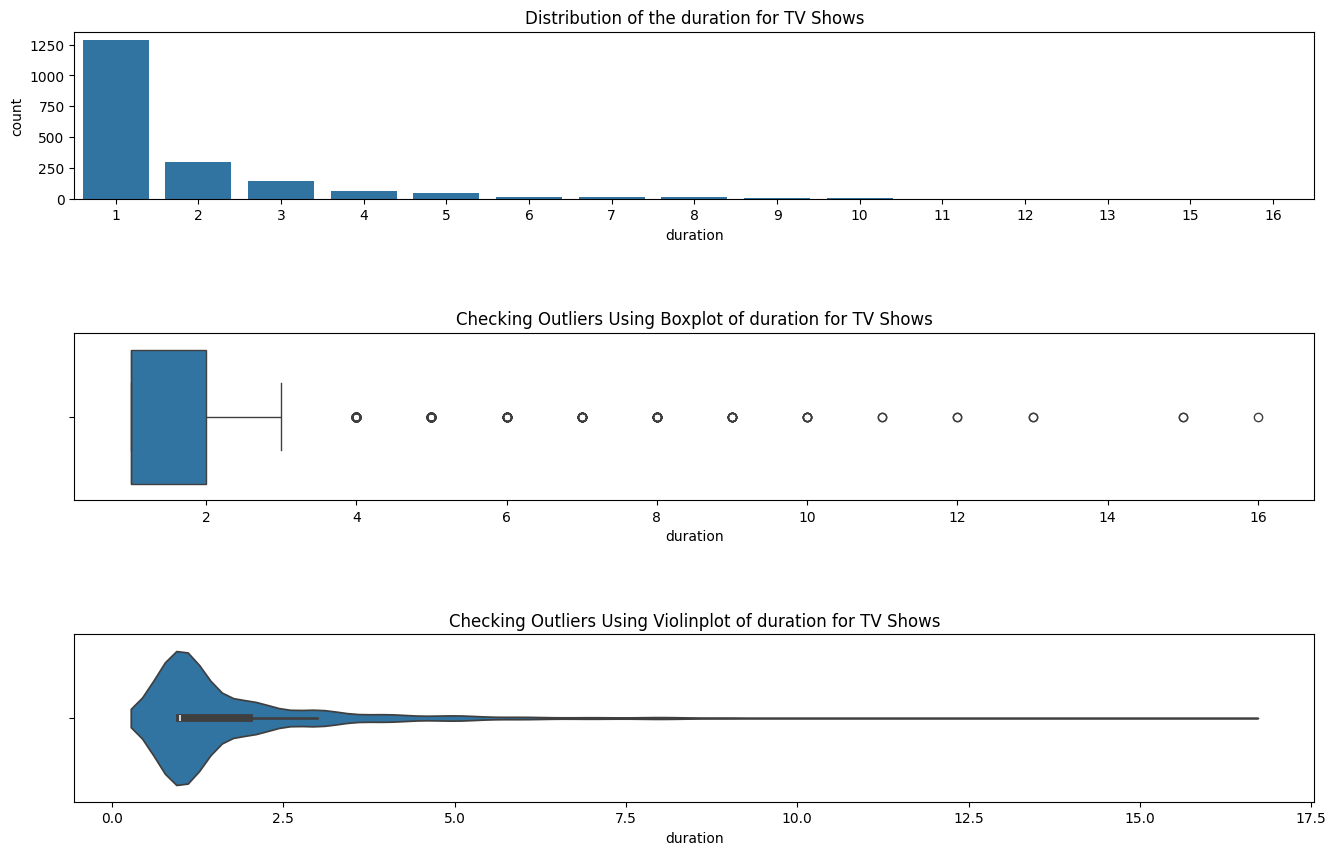

In [ ]:
# for `duration`
fig, axes = plt.subplots(3, 1, figsize=(16, 10))
sns.countplot(data=df[df['type'] == 'TV Show'], x='duration', ax=axes[0])
sns.boxplot(data=df[df['type'] == 'TV Show'], x='duration', ax=axes[1])
sns.violinplot(data=df[df['type'] == 'TV Show'], x='duration', ax=axes[2])

axes[0].set_title('Distribution of the duration for TV Shows')
axes[1].set_title('Checking Outliers Using Boxplot of duration for TV Shows')
axes[2].set_title('Checking Outliers Using Violinplot of duration for TV Shows')

plt.subplots_adjust(hspace=0.8)
plt.show()

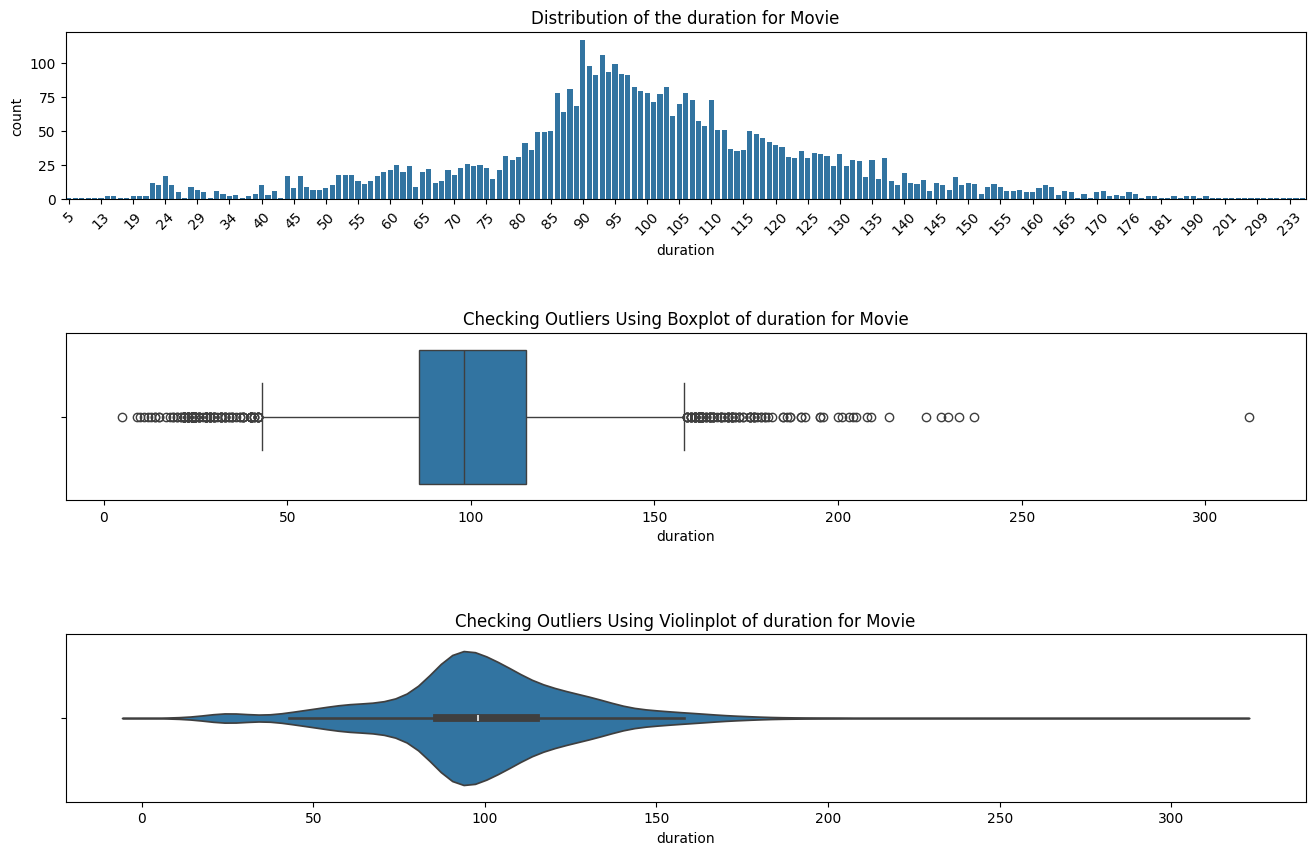

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(16, 10))
sns.countplot(data=df[df['type'] == 'Movie'], x='duration', ax=axes[0])
sns.boxplot(data=df[df['type'] == 'Movie'], x='duration', ax=axes[1])
sns.violinplot(data=df[df['type'] == 'Movie'], x='duration', ax=axes[2])

axes[0].set_title('Distribution of the duration for Movie')
axes[1].set_title('Checking Outliers Using Boxplot of duration for Movie')
axes[2].set_title('Checking Outliers Using Violinplot of duration for Movie')

ticks = axes[0].get_xticks()
labels = [item.get_text() for item in axes[0].get_xticklabels()]
axes[0].set_xticks(ticks[::5])
axes[0].set_xticklabels(labels[::5], rotation=45)

plt.subplots_adjust(hspace=0.8)
plt.show()

### 2.   Who is the actor who has worked in the cast with the most actors?

Anupam Kher, with 220 cinemas.

In [ ]:
from collections import defaultdict
cast_dict = defaultdict(set)

for cast in df['cast'].dropna():
    actors = cast.split(', ')
    for actor in actors:
        cast_dict[actor].update([act for act in actors if act != actor]) # acts != actor might be reductant

# creating a dictionary with coactor counts
coactor_count = {}
for actor, coactors in cast_dict.items():
    coactor_count[actor] = len(coactors)


In [ ]:
coactor_count_df = pd.DataFrame()

coactor_count_df = pd.DataFrame(list(coactor_count.items()), columns=['Actors', 'coactor_count'])
coactor_count_df = coactor_count_df.sort_values(by='coactor_count', ascending=False)
coactor_count_df.shape

(27988, 2)

In [ ]:
coactor_count_df.head(3)

,Actors,coactor_count
2050,Anupam Kher,220
305,Fred Tatasciore,194
633,Takahiro Sakurai,189


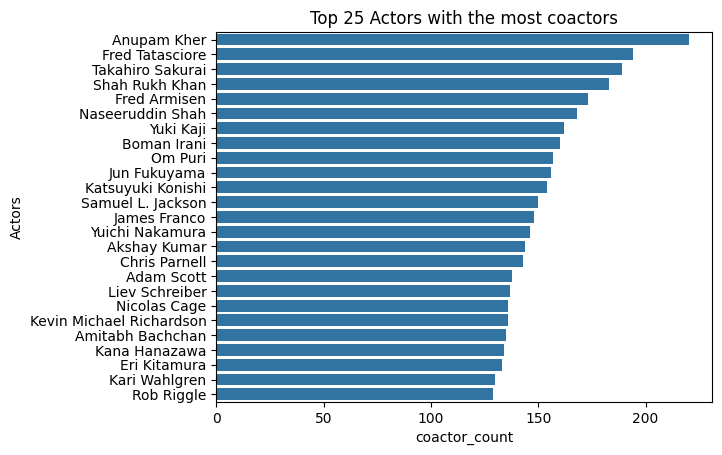

In [ ]:
# plotting first 25 actors
sns.barplot(data=coactor_count_df.head(25), x='coactor_count', y='Actors')
plt.title('Top 25 Actors with the most coactors')
plt.show()

### 3.   Which actor has worked in more films?

Anupam Kher, in 33 cinemas.

In [ ]:
actors = []
for cast in df['cast'].dropna():
    actors.extend(cast.split(', '))

actors_df = pd.DataFrame(actors, columns=['Actors'])

actors_df_counts = actors_df['Actors'].value_counts().head(13).to_frame().reset_index()
actors_df_counts.columns = ['Actors', 'Count']

In [ ]:
actors_df_counts.head(3)

,Actors,Count
0,Anupam Kher,33
1,Naseeruddin Shah,29
2,Shah Rukh Khan,27


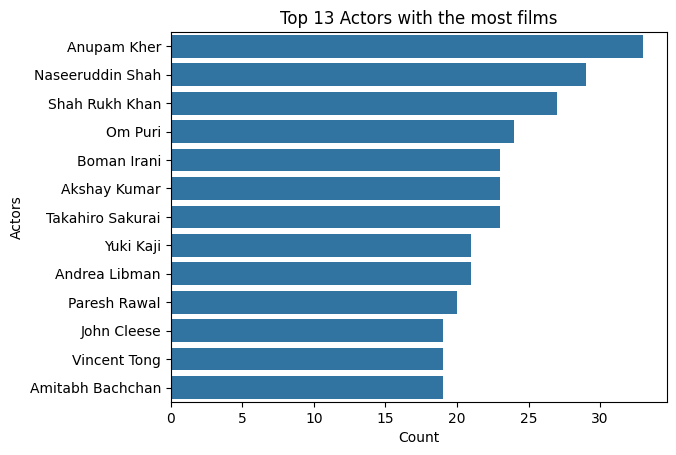

In [ ]:
sns.barplot(data=actors_df_counts, x='Count', y='Actors')
plt.title('Top 13 Actors with the most films')
plt.show()

In [ ]:
# actor_counter = {}

# for actor in actors:
#     if actor in actor_counter:
#         actor_counter[actor] += 1
#     else:
#         actor_counter[actor] = 1

# max_actor_num = max(actor_counter, key=actor_counter.get)

# print(f"The actor who has worked in more films is {max_actor_num} with {actor_counter[max_actor_num]} films.")

The actor who has worked in more films is Anupam Kher with 33 films.


### 4.   How many films has each director made, and what is the genre of each film he has made?

In [ ]:
df_director = df.dropna(subset=['director'])
df_director.loc[:, 'director'] = df_director['director'].str.split(',')

df_director_new = df_director.explode('director')
df_director_new['director'] = df_director_new['director'].str.strip()


In [ ]:
# counting films from each directors --> essentially # of times a director has appeared in the column
film_counts = df_director_new['director'].value_counts().to_frame().reset_index()
film_counts.columns = ['director', 'film_count']

In [ ]:
# getting the genres of each director
df_director_genre = df_director_new.groupby('director')['genre'].apply(lambda x: ', '.join(sorted(set(x)))).reset_index()

In [ ]:
# merging two dataframes
director_film_genre = pd.merge(film_counts, df_director_genre, on='director')
director_film_genre.head(5)

,director,film_count,genre
0,Jan Suter,18,Stand-Up
1,Raúl Campos,16,Stand-Up
2,Jay Karas,13,"Children, Stand-Up"
3,Cathy Garcia-Molina,12,"Comedies, Dramas, International Movies"
4,Marcus Raboy,12,Stand-Up


### 5.  In which year have the most films been made in the U.S.? And in which year in Brazil?

In [ ]:
# United States
df[df['country'] == 'United States'].dropna(subset=['country']).groupby('release_year').size().sort_values(ascending=False).reset_index(name='film_count').head(3)


,release_year,film_count
0,2017,313
1,2018,293
2,2019,293


In [ ]:
# Brazil
df[df['country'] == 'Brazil'].dropna(subset=['country']).groupby('release_year').size().sort_values(ascending=False).reset_index(name='film_count').head(3)

,release_year,film_count
0,2020,19
1,2019,15
2,2018,9


In [ ]:
df[df['country'] == 'India'].dropna(subset=['country']).groupby('release_year').size().sort_values(ascending=False).reset_index(name='film_count').head(3)

,release_year,film_count
0,2018,85
1,2017,81
2,2019,79


### 6.   Taking into consideration the duration of each film, which director shot the most minutes?

I have chosen to separeate `Movies` and `TV Show` for this. As it doesn't make sense to add minutes to number of seasons.

In [ ]:
# For Movies
df_director_new[df_director_new['type'] == 'Movie'].groupby('director')['duration'].sum().sort_values(ascending=False).reset_index(name='duration').head(3)

,director,duration
0,Martin Scorsese,1579
1,Cathy Garcia-Molina,1432
2,Jan Suter,1155


### 7.   Taking into consideration the duration of each film, which director shot the most minutes?

In [ ]:
# For TV Show
df_director_new[df_director_new['type'] == 'TV Show'].groupby('director')['duration'].sum().sort_values(ascending=False).reset_index(name='duration').head(3)

,director,duration
0,Phil Sgriccia,15
1,Hayato Date,9
2,Philippa Lowthorpe,9


### 8.   Which actor shot the most minutes in total?

In [ ]:
df_actors = df.dropna(subset=['cast'])
df_actors.loc[:, 'cast'] = df_actors['cast'].str.split(',')

df_actors_new = df_actors.explode('cast')
df_actors_new['cast'] = df_actors_new['cast'].str.strip()

In [ ]:
# For Movies
(df_actors_new[df_actors_new['type'] == 'Movie']
 .groupby('cast')['duration']
 .sum().sort_values(ascending=False)
 .reset_index(name='duration').head(3))

,cast,duration
0,Anupam Kher,4441
1,Shah Rukh Khan,4213
2,Naseeruddin Shah,3804


In [ ]:
# For TV Series
(df_actors_new[df_actors_new['type'] == 'TV Show']
 .groupby('cast')['duration'].sum()
 .sort_values(ascending=False)
 .reset_index(name='duration').head(3))

,cast,duration
0,Vincent Tong,27
1,Kate Walsh,27
2,Takahiro Sakurai,26


## 2️⃣ Unsupervised Learning

It often happens that when we see a movie we like, we look for a new movie that has a similar plot!
Are you able, based on the plots of these movies, to find clusters? How many clusters have you found? Could you also visualize in a 2D or 3D chart?

**Tip**: I think there is a need to create embedding of descriptions... 🤔

![](https://carpenter-singh-lab.broadinstitute.org/files/styles/original/public/anne/files/browser-based_p1_compressed.gif?itok=su5EM3Vp)


### Embedding

Embedding has been done using the Sentence Transformer model from Hugging Face.

In [ ]:
# embedding
# we will use Sentence Transformer from Hugging Face

model_st = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

embed_description = model_st.encode(df['description'].to_list(),
                                    show_progress_bar=True,
                                    normalize_embeddings=True,
                                    batch_size=64)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/98 [00:00<?, ?it/s]

### Handle Missing Values

Replacing missing values with `_Missing_` tag.

In [ ]:

df = df.drop(['date_added', 'date_added_parsed'], axis=1)

df.head(3)

,type,title,director,cast,country,release_year,duration,description,genre,year_added,month_added,lag_years
0,TV Show,The Big Family Cooking Showdown,_Missing_,"Zoe Ball, Nadiya Hussain, Giorgio Locatelli, R...",United Kingdom,2018,2,"In this unscripted series, families passionate...",British TV,2019,2,1
1,TV Show,The World's Most Extraordinary Homes,_Missing_,"Piers Taylor, Caroline Quentin",United Kingdom,2019,3,Award-winning architect Piers Taylor and actre...,British TV,2019,1,0
2,TV Show,One-Punch Man,_Missing_,"Makoto Furukawa, Kaito Ishikawa, Yuki Kaji, Ao...",Japan,2015,1,The most powerful superhero in the world can k...,Anime Series,2017,3,2


In [ ]:
# dimensionality reduction using t-SNE

from sklearn.manifold import TSNE
from mpl_toolkits.mplot3d import Axes3D


# t-SNE for 2D and 3D visualization

perplexity = 30
init = 'pca'
max_iter = 2000


# 2D embeddings
tsne_2d = TSNE(perplexity=perplexity, n_components=2, init=init, max_iter=max_iter, random_state=42)
embeddings_2d = tsne_2d.fit_transform(embed_description)

# 3D embeddings
tsne_3d = TSNE(perplexity=perplexity, n_components=3, init=init, max_iter=max_iter, random_state=42)
embeddings_3d = tsne_3d.fit_transform(embed_description)


In [ ]:
# K-Means clustering to decide optimal number of clusters

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

l2_distances = []
k_range = range(2, 15)
for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init=10)
    kmeans = kmeans.fit(embed_description_umap)
    l2_distances.append(kmeans.inertia_)

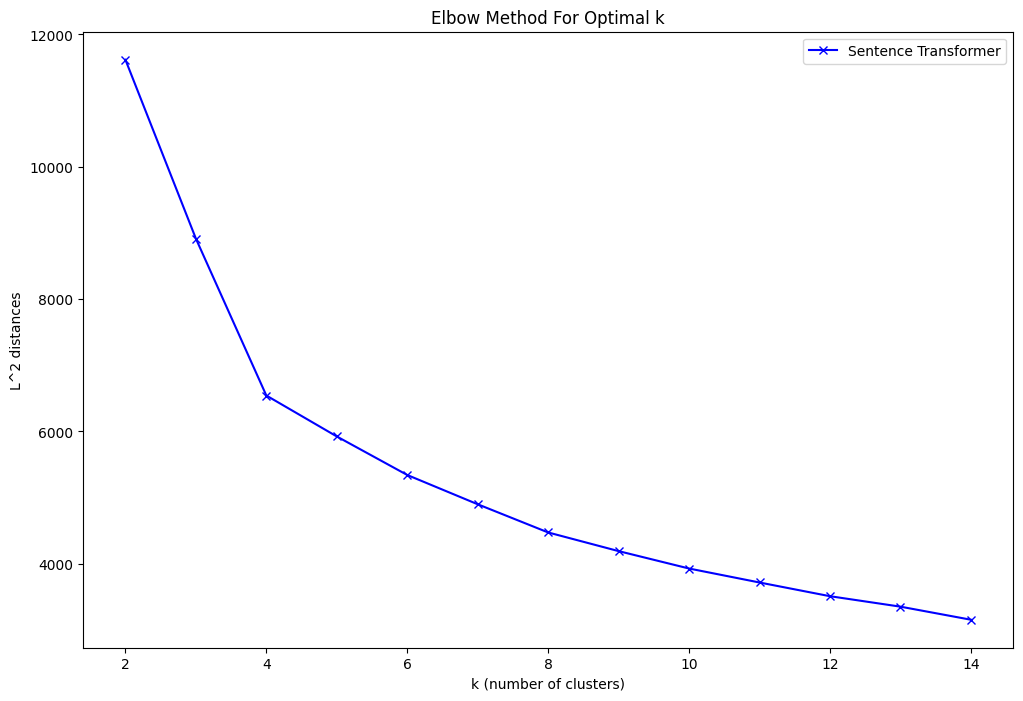

In [ ]:
plt.figure(figsize=(12, 8))
plt.plot(k_range, l2_distances, 'bx-', label="Sentence Transformer")
plt.xlabel('k (number of clusters)')
plt.ylabel('L^2 distances')
plt.title('Elbow Method For Optimal k')
plt.legend()
plt.show()

Optimal cluster value: $k \in \{4, 5, 6\}$.

In [ ]:
# Performing K-means clustering

opt_clusters = 4  # choosing optimal clusters = 4, based on Silohuette score calculated later

# 2D clustering
kmeans_2d = KMeans(n_clusters=opt_clusters, n_init=10).fit(embeddings_2d)
labels_2d = kmeans_2d.labels_

# 3D clustering
kmeans_3d = KMeans(n_clusters=opt_clusters, n_init=10).fit(embeddings_3d)
labels_3d = kmeans_3d.labels_

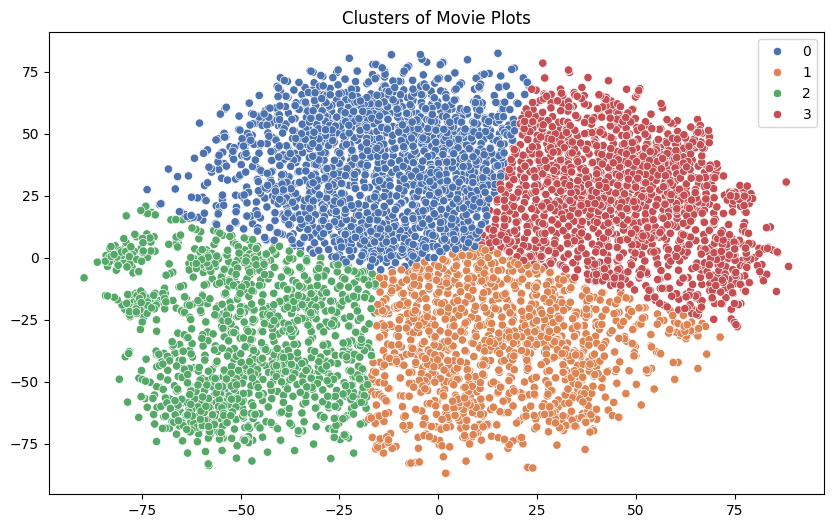

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=embeddings_2d[:, 0], y=embeddings_2d[:, 1], hue=labels_2d, palette="deep")
plt.title("Clusters of Movie Plots")
plt.show()

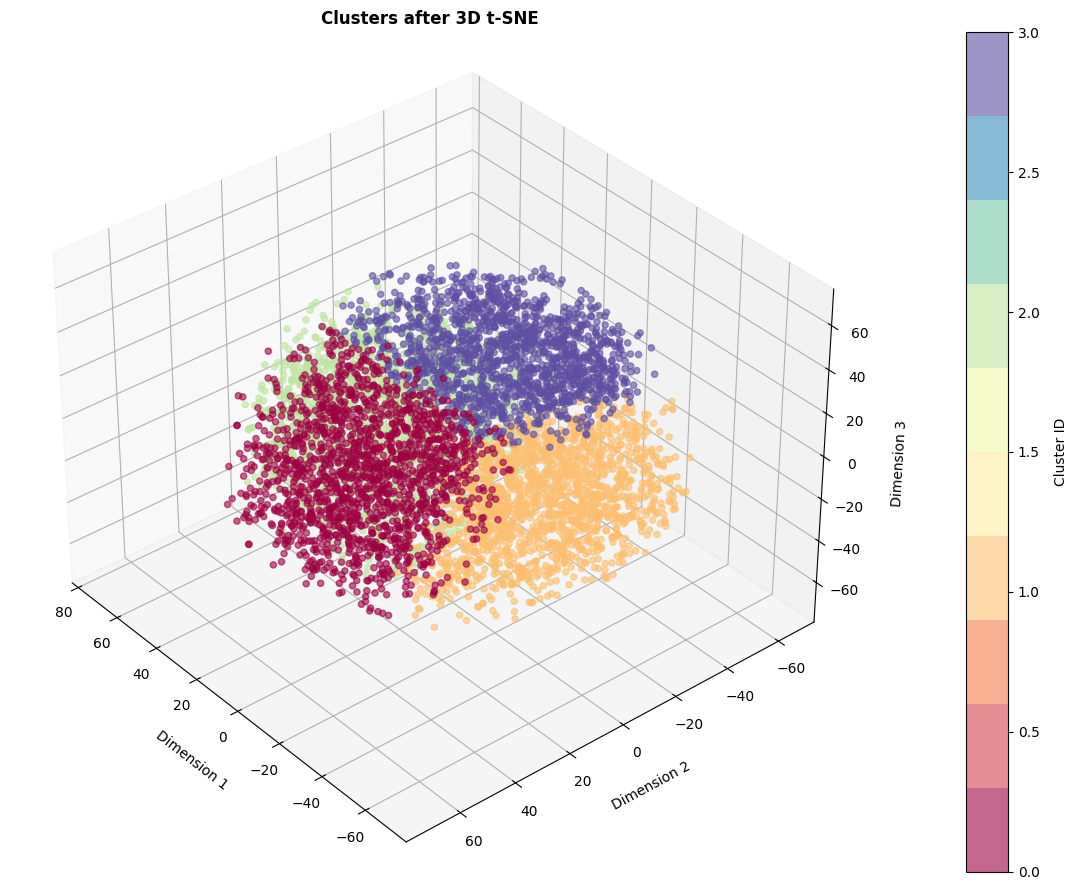

In [ ]:
# 3d clustering plot

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot
scatter = ax.scatter(embeddings_3d[:, 0],
                     embeddings_3d[:, 1],
                     embeddings_3d[:, 2],
                     c=labels_3d,
                     cmap=plt.get_cmap('Spectral', 10),
                     s=20,
                     alpha=0.6)


ax.set_title("Clusters after 3D t-SNE", fontweight='bold')
ax.set_xlabel('Dimension 1', labelpad=10)
ax.set_ylabel('Dimension 2', labelpad=10)
ax.set_zlabel('Dimension 3', labelpad=10)
ax.grid(True, linestyle='--')

# Colors
cbar = fig.colorbar(scatter, ax=ax, pad=0.1)
cbar.set_label('Cluster ID', rotation=90, labelpad=10)

ax.view_init(elev=35, azim=140)  # different perspective

plt.tight_layout()
plt.show()

In [ ]:
# Performace of the cluster

silhouette_score(embeddings_2d, labels_2d)

np.float32(0.39636165)

In [ ]:
# Some values from clusters

df_cluster = pd.DataFrame()

# define a cluster df
df_cluster = df[['title', 'genre']].copy()
df_cluster['cluster'] = labels_2d

# consider two clusters 0 and 1
cluster_0 = df_cluster[df_cluster['cluster'] == 0]
cluster_1 = df_cluster[df_cluster['cluster'] == 1]

# Randomly select 5 points from each of clusters 0 and 1
random_points_cluster_0 = cluster_0.sample(n=5, random_state=40)
random_points_cluster_1 = cluster_1.sample(n=5, random_state=40)

print("Cluster 0:")
print(random_points_cluster_0[['title', 'genre']])
print('\n')

print("Cluster 1:")
print(random_points_cluster_1[['title', 'genre']])

Cluster 0:
               title     genre
6216    River's Edge    Dramas
5175       Sleepover  Comedies
5634      #Selfie 69  Comedies
4293  Ordinary World  Comedies
4556     4th Man Out  Comedies


Cluster 1:
                   title             genre
3370         Ice Fantasy  International TV
6163      Mutant Busters              Kids
340     The Dark Crystal          Children
5010  Arthdal Chronicles  International TV
264              Rocky V            Dramas


With the Silhouette score of ~0.4, we see that our cluster is fairly decent.

## 3️⃣ Supervised Learning - Classification
In this exercise, you will use the variable "Genre" as the classification target to create atleast 2 classification models (1st : Classical ML Model, 2nd : Deep Learning Model) using the rest of the variables as features. Given that we have a mix of text and numerical data, you can use a machine learning/deep learning model also to embed the features of the text along with the other variables. Please considering doing the following :
1. Plot and comment on the data distribution
2. Justify your choice of method/model for embedding and for classification
3. Identify the appropriate metrics for the task
4. Plot the metrics and comment on the performance of the model


![](https://thumbs.gfycat.com/SecondaryDapperCopperbutterfly-size_restricted.gif)

In the following codeblock, I have mapped `genres` into broader categories, since there are overlapps between genres. For examples, a Drama movie can be Romantic as well.

Here are the following categories:

1. **Drama & Romance**:
   - Dramas
   - Crime TV
   - TV Dramas
   - Romantic TV
   - Classic Movies
   - Independent Movies
   - Classic

2. **Comedy & Light Entertainment**:
   - Comedies
   - Stand-Up
   - TV Comedies
   - Children
   - Kids

3. **Action & Thrillers**:
   - Action
   - Horror Movies
   - Thrillers
   - TV Action
   - Sci-Fi
   - TV Horror

4. **Documentaries & Informative**:
   - Documentaries
   - Docuseries
   - International TV
   - British TV
   - Reality TV
   - TV Shows

5. **International & Niche**:
   - International Movies
   - Anime Series
   - Anime Features
   - Cult Movies
   - Music
   - Uncategorized

In [ ]:
# mapping genre into broader genres, and doing label encoding
genre_mapping = {
    'Dramas': 'Drama & Romance', 'Crime TV': 'Drama & Romance',
    'TV Dramas': 'Drama & Romance', 'Romantic TV': 'Drama & Romance',
    'Classic Movies': 'Drama & Romance', 'Independent Movies': 'Drama & Romance',
    'Classic': 'Drama & Romance',

    'Comedies': 'Comedy & Light Entertainment', 'Stand-Up': 'Comedy & Light Entertainment',
    'TV Comedies': 'Comedy & Light Entertainment', 'Children': 'Comedy & Light Entertainment',
    'Kids': 'Comedy & Light Entertainment',

    'Action': 'Action & Thrillers', 'Horror Movies': 'Action & Thrillers',
    'Thrillers': 'Action & Thrillers', 'TV Action': 'Action & Thrillers',
    'Sci-Fi': 'Action & Thrillers', 'TV Horror': 'Action & Thrillers',

    'Documentaries': 'Documentaries & Informative', 'Docuseries': 'Documentaries & Informative',
    'International TV': 'Documentaries & Informative', 'British TV': 'Documentaries & Informative',
    'Reality TV': 'Documentaries & Informative', 'TV Shows': 'Documentaries & Informative',

    'International Movies': 'International & Niche', 'Anime Series': 'International & Niche',
    'Anime Features': 'International & Niche', 'Cult Movies': 'International & Niche',
    'Music': 'International & Niche', 'Uncategorized': 'International & Niche'
}

df["broad_genre"] = df["genre"].map(genre_mapping)

# label encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["broad_genre"] = le.fit_transform(df["broad_genre"])

In [ ]:
df.head(3)

,type,title,director,cast,country,release_year,duration,description,genre,year_added,month_added,lag_years,broad_genre
0,TV Show,The Big Family Cooking Showdown,_Missing_,"Zoe Ball, Nadiya Hussain, Giorgio Locatelli, R...",United Kingdom,2018,2,"In this unscripted series, families passionate...",British TV,2019,2,1,2
1,TV Show,The World's Most Extraordinary Homes,_Missing_,"Piers Taylor, Caroline Quentin",United Kingdom,2019,3,Award-winning architect Piers Taylor and actre...,British TV,2019,1,0,2
2,TV Show,One-Punch Man,_Missing_,"Makoto Furukawa, Kaito Ishikawa, Yuki Kaji, Ao...",Japan,2015,1,The most powerful superhero in the world can k...,Anime Series,2017,3,2,4


In [ ]:
df = df.drop(['genre'], axis=1)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

In the following two codeblocks, I am distinguishing top 15 countries and top 15 directors given their frequency levels, and rest are kept as `Other`. This also helps our code to be faster.

In [ ]:
# Top 15 countries
TOP_N_COUNTRIES = 15
top_countries = df["country"].value_counts().nlargest(TOP_N_COUNTRIES).index
df["country"] = np.where(df["country"].isin(top_countries), df["country"], "Other")

In [ ]:
# Top 15 directors
TOP_N_DIRECTORS = 15
top_directors = df["director"].value_counts().nlargest(TOP_N_DIRECTORS).index
df["director"] = np.where(df["director"].isin(top_directors), df["director"], "Other")

We combine `title` and `description` and encode them using `SentenceTransformer`.

In [ ]:
# combining title and description as text for encoding using SentenceTransformer
df["text"] = (df["title"] + ". " + df["description"]).astype(str)

embeddings = model_st.encode(
    df["text"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True
)

Batches:   0%|          | 0/98 [00:00<?, ?it/s]

In the following block, we seperate categorical and numerical columns. We encode categorical columns with `OneHotEncoder` and scale numerical variables for consistency in the model.

In [ ]:
import scipy

cat_cols = ["type", "country", "director", "month_added"]
num_cols = ["release_year", "duration", "lag_years", "year_added"]

# Preprocessing for tabular data
tab_preproc = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", StandardScaler(), num_cols),
    ],
    remainder="drop"
)

X_tab = tab_preproc.fit_transform(df[cat_cols + num_cols])

# Join embeddings + tabular
from scipy.sparse import hstack
X_full = np.hstack([embeddings, X_tab.toarray()])   # final array

y = df["broad_genre"]

### Training

I have chosen Logistic Regression and Random Forest. Random Forest is chosen due to having mixtures of input features. Even though, we have imputed missing values using missing indicators, RF can deal will missing values.

In [ ]:
# Split Train and Validation Data
X_train, X_val, y_train, y_val = train_test_split(
    X_full, y, test_size=0.2, stratify=y, random_state=13
)

In [ ]:
# Logistic Regression

clf = LogisticRegression(
    max_iter=500,
    class_weight="balanced",
    n_jobs=-1
)
model_log = clf.fit(X_train, y_train) # for future use, in-case

In [ ]:
# Random Forest
rf = RandomForestClassifier(
        n_estimators=400,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        n_jobs=-1,
        class_weight="balanced_subsample",
        random_state=13
    )

model_rf = rf.fit(X_train, y_train) # for future use, in-case

In [ ]:
# A function to evaluate ML models

def eval(name, model, X_val, y_val):
    print(f" {name} ")
    preds = model.predict(X_val)
    acc = accuracy_score(y_val, preds)
    f1_macro = f1_score(y_val, preds, average="macro")
    f1_weighted = f1_score(y_val, preds, average="weighted")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1 (macro): {f1_macro:.4f} | F1 (weighted): {f1_weighted:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_val, preds, digits=4))
    print("Confusion Matrix:")
    print(confusion_matrix(y_val, preds))

In [ ]:
eval("Logistic Regression", model_log, X_val, y_val)

 Logistic Regression 
Accuracy: 0.5759
F1 (macro): 0.5401 | F1 (weighted): 0.5776

Classification Report:
              precision    recall  f1-score   support

           0     0.4836    0.5988    0.5351       172
           1     0.6543    0.5521    0.5989       384
           2     0.6786    0.7192    0.6983       317
           3     0.5177    0.4650    0.4899       314
           4     0.3111    0.4828    0.3784        58

    accuracy                         0.5759      1245
   macro avg     0.5291    0.5636    0.5401      1245
weighted avg     0.5865    0.5759    0.5776      1245

Confusion Matrix:
[[103  20   8  31  10]
 [ 35 212  47  64  26]
 [ 10  35 228  34  10]
 [ 58  45  49 146  16]
 [  7  12   4   7  28]]


In [ ]:
eval("RandomForest", model_rf, X_val, y_val)

 RandomForest 
Accuracy: 0.5831
F1 (macro): 0.4971 | F1 (weighted): 0.5625

Classification Report:
              precision    recall  f1-score   support

           0     0.7037    0.3314    0.4506       172
           1     0.5421    0.7370    0.6247       384
           2     0.6408    0.7823    0.7045       317
           3     0.5263    0.4140    0.4635       314
           4     1.0000    0.1379    0.2424        58

    accuracy                         0.5831      1245
   macro avg     0.6826    0.4805    0.4971      1245
weighted avg     0.6069    0.5831    0.5625      1245

Confusion Matrix:
[[ 57  64   8  43   0]
 [  3 283  49  49   0]
 [  8  48 248  13   0]
 [ 10 101  73 130   0]
 [  3  26   9  12   8]]


### Test Data Preprocessing

In [ ]:
# test data preprocessing for model predictions

df_test = df_test_org.copy()
df_test = df_test.drop(['show_id'], axis=1)
df_test['director'] = df_test['director'].fillna('_Missing_')
df_test['cast'] = df_test['cast'].fillna('_Missing_')
df_test['country'] = df_test['country'].fillna('_Missing_')
df_test['date_added'] = df_test['date_added'].fillna('_Missing_')

In [ ]:
# parsing date-time
df_test["date_added_parsed"] = pd.to_datetime(
    df_test["date_added"].replace("_Missing_", pd.NA), # this step could have been avoided.
    errors="coerce"
)

# year and month
df_test["year_added"] = df_test["date_added_parsed"].dt.year
df_test["month_added"] = df_test["date_added_parsed"].dt.month

# Handle missing parsed dates
df_test["year_added"] = df_test["year_added"].fillna(df_test["year_added"].median()).astype(int)
df_test["month_added"] = df_test["month_added"].fillna(0).astype(int)  # 0 = _Missing_

# Difference between release and addition to database of Netflix
df_test["lag_years"] = df_test["year_added"] - df_test["release_year"]

In [ ]:
# Top 15 countries
TOP_N_COUNTRIES = 15
top_countries = df_test["country"].value_counts().nlargest(TOP_N_COUNTRIES).index
df_test["country"] = np.where(df_test["country"].isin(top_countries), df_test["country"], "Other")

In [ ]:
# Top 15 directors
TOP_N_DIRECTORS = 15
top_directors = df_test["director"].value_counts().nlargest(TOP_N_DIRECTORS).index
df_test["director"] = np.where(df_test["director"].isin(top_directors), df_test["director"], "Other")

In [ ]:
# combining title and description as text for encoding using SentenceTransformer
df_test["text"] = (df_test["title"] + ". " + df_test["description"]).astype(str)

embeddings_test = model_st.encode(
    df_test["text"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True
)

X_tab_test = tab_preproc.fit_transform(df_test[cat_cols + num_cols])

# Join embeddings + tabular
X_full_test = np.hstack([embeddings_test, X_tab_test.toarray()])   # final array

Batches:   0%|          | 0/25 [00:00<?, ?it/s]

In [ ]:
predictions_rf = model_rf.predict(X_full_test)
predictions_names = le.inverse_transform(predictions_rf)

### Some Sample Predictions

In [ ]:
df_test_pred = df_test.copy()
df_test_pred["predicted_genre"] = predictions_names
df_test_pred.head(3)

,type,title,director,cast,country,date_added,release_year,duration,description,date_added_parsed,year_added,month_added,lag_years,text,predicted_genre
0,Movie,What Happened to Mr. Cha?,Other,"Cha In-pyo, Cho Dal-hwan, Song Jae-ryong",South Korea,"January 1, 2021",2021,102,"With the peak of his career long behind him, a...",2021-01-01,2021,1,0,What Happened to Mr. Cha?. With the peak of hi...,Comedy & Light Entertainment
1,Movie,American Factory,Other,_Missing_,United States,"August 21, 2019",2019,110,"In this documentary, hopes soar when a Chinese...",2019-08-21,2019,8,0,"American Factory. In this documentary, hopes s...",Documentaries & Informative
2,TV Show,Gentefied,_Missing_,"J.J. Soria, Carlos Santos, Karrie Martin, Joaq...",United States,"February 21, 2020",2020,1,The Morales cousins scramble to save their gra...,2020-02-21,2020,2,0,Gentefied. The Morales cousins scramble to sav...,Documentaries & Informative


### A Simple MLP model using PyTorch

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

In [ ]:
# pytorch dataset loader
class PyDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y.values).long() # Convert Series to NumPy array
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = PyDataset(X_train, y_train)
val_ds   = PyDataset(X_val, y_val)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=128, shuffle=False, num_workers=0)

In [ ]:
# class weights
class_counts = np.bincount(y)
class_weights = (class_counts.sum() / (class_counts + 1e-9))
class_weights = class_weights / class_weights.mean()  # normalize
class_weights_t = torch.tensor(class_weights, dtype=torch.float32)

In [ ]:
# Preparing MLP
in_dim = X_full.shape[1]
hidden = 512  # tune 256–1024
drop = 0.3

class MLP(nn.Module):
    def __init__(self, in_dim, hidden, num_classes, drop=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(), # activation
            nn.Dropout(drop),
            nn.Linear(hidden, hidden//2),
            nn.ReLU(),
            nn.Dropout(drop),
            nn.Linear(hidden//2, num_classes),
        )
    def forward(self, x):
        return self.net(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MLP(in_dim, hidden, len(le.classes_), drop).to(device)

In [ ]:
# Loss Function
criterion = nn.CrossEntropyLoss(weight=class_weights_t.to(device))
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

best_f1 = 0.0
patience, patience_ctr = 5, 0

In [ ]:
def eval_loop():
    model.eval()
    all_y, all_p = [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb.float())
            preds = logits.argmax(dim=1)
            all_y.append(yb.cpu().numpy())
            all_p.append(preds.cpu().numpy())
    y_true = np.concatenate(all_y)
    y_pred = np.concatenate(all_p)
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro")
    return acc, f1m, y_true, y_pred

for epoch in range(30):
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb.float())
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

    acc, f1m, y_true, y_pred = eval_loop()
    scheduler.step(f1m)
    print(f"Epoch {epoch+1:02d} | Val Acc {acc:.4f} | Val F1-macro {f1m:.4f}")

    if f1m > best_f1:
        best_f1 = f1m
        patience_ctr = 0
        torch.save({"state_dict": model.state_dict(),
                    "label_encoder": le,
                    "ct": tab_preproc}, "mlp_genre_best.pt")
    else:
        patience_ctr += 1
        if patience_ctr >= patience:
            print("Early stopping.")
            break

Epoch 01 | Val Acc 0.5751 | Val F1-macro 0.5311
Epoch 02 | Val Acc 0.5695 | Val F1-macro 0.5279
Epoch 03 | Val Acc 0.6177 | Val F1-macro 0.5740
Epoch 04 | Val Acc 0.6329 | Val F1-macro 0.5786
Epoch 05 | Val Acc 0.6450 | Val F1-macro 0.5882
Epoch 06 | Val Acc 0.6402 | Val F1-macro 0.5933
Epoch 07 | Val Acc 0.6281 | Val F1-macro 0.5750
Epoch 08 | Val Acc 0.6602 | Val F1-macro 0.6084
Epoch 09 | Val Acc 0.6369 | Val F1-macro 0.5853
Epoch 10 | Val Acc 0.6418 | Val F1-macro 0.5898
Epoch 11 | Val Acc 0.6225 | Val F1-macro 0.5664
Epoch 12 | Val Acc 0.6546 | Val F1-macro 0.6009
Epoch 13 | Val Acc 0.6498 | Val F1-macro 0.5939
Early stopping.


### Classification Report

In [ ]:
print(classification_report(y_true, y_pred, target_names=le.classes_))

                              precision    recall  f1-score   support

          Action & Thrillers       0.50      0.61      0.55       172
Comedy & Light Entertainment       0.67      0.74      0.71       384
 Documentaries & Informative       0.80      0.81      0.80       317
             Drama & Romance       0.56      0.46      0.51       314
       International & Niche       0.58      0.31      0.40        58

                    accuracy                           0.65      1245
                   macro avg       0.62      0.59      0.59      1245
                weighted avg       0.65      0.65      0.64      1245



### Some Predictions

In [ ]:
# test loader
test_tensor = torch.from_numpy(X_full_test)
test_loader   = DataLoader(test_tensor, batch_size=128, shuffle=False, num_workers=0)

def predict_loader(loader):
    model.eval()
    preds = []
    with torch.no_grad():
        for xb in loader:                   # or: for xb, _ in loader
            if isinstance(xb, (list, tuple)): xb = xb[0]
            preds.append(model(xb.to(device).float()).argmax(1).cpu().numpy())
    return np.concatenate(preds)

y_pred_test = predict_loader(test_loader)

predictions_names_mlp = le.inverse_transform(y_pred_test)

In [ ]:
df_test_pred_mlp = df_test.copy()
df_test_pred_mlp["predicted_genre"] = predictions_names_mlp
df_test_pred_mlp.head(3)

,type,title,director,cast,country,date_added,release_year,duration,description,date_added_parsed,year_added,month_added,lag_years,text,predicted_genre
0,Movie,What Happened to Mr. Cha?,Other,"Cha In-pyo, Cho Dal-hwan, Song Jae-ryong",South Korea,"January 1, 2021",2021,102,"With the peak of his career long behind him, a...",2021-01-01,2021,1,0,What Happened to Mr. Cha?. With the peak of hi...,Drama & Romance
1,Movie,American Factory,Other,_Missing_,United States,"August 21, 2019",2019,110,"In this documentary, hopes soar when a Chinese...",2019-08-21,2019,8,0,"American Factory. In this documentary, hopes s...",Documentaries & Informative
2,TV Show,Gentefied,_Missing_,"J.J. Soria, Carlos Santos, Karrie Martin, Joaq...",United States,"February 21, 2020",2020,1,The Morales cousins scramble to save their gra...,2020-02-21,2020,2,0,Gentefied. The Morales cousins scramble to sav...,Comedy & Light Entertainment


###Optional

If you prefer you can solve this task usign a LLM as a classifier! Otherwise go with standard solutions.

In [ ]:
#start your code here!

## 4️⃣ Statistics for Model Selection

In this section you should compare the models that you trained in the previous section using statistical tests and justify your choice of model.
**Hint:** Use the McNemar Test

In [ ]:
y_predictions_mlp = predict_loader(val_loader)
y_predictions_rf = model_rf.predict(X_val)
y_predictions_log = model_log.predict(X_val)

In [ ]:
from statsmodels.stats.contingency_tables import mcnemar

# contingency table RF and MLP
n01 = np.sum((y_predictions_rf == y_val) & (y_predictions_mlp != y_val))  # RF correct, MLP wrong
n10 = np.sum((y_predictions_rf != y_val) & (y_predictions_mlp == y_val))  # RF wrong, MLP correct
table = [[0, n01], [n10, 0]]

# McNemar test
result = mcnemar(table, exact=False, correction=True)
print("Statistic:", result.statistic, "p-value:", result.pvalue)

# Interpretation
if result.pvalue < 0.05:
    print("Reject H0: The difference is statistically significant.")
else:
    print("Fail to reject H0: No significant difference between models.")


Statistic: 19.48985507246377 p-value: 1.0113539160609868e-05
Reject H0: The difference is statistically significant.


In [ ]:
# contingency table RF and MLP
n01 = np.sum((y_predictions_log == y_val) & (y_predictions_mlp != y_val))  # Logistic correct, MLP wrong
n10 = np.sum((y_predictions_log != y_val) & (y_predictions_mlp == y_val))  # Logistic wrong, MLP correct
table = [[0, n01], [n10, 0]]

# McNemar test
result = mcnemar(table, exact=False, correction=True)
print("Statistic:", result.statistic, "p-value:", result.pvalue)

# Interpretation
if result.pvalue < 0.05:
    print("Reject H0: The difference is statistically significant.")
else:
    print("Fail to reject H0: No significant difference between models.")

Statistic: 28.35958904109589 p-value: 1.0074653133181988e-07
Reject H0: The difference is statistically significant.


In [ ]:
# contingency table RF and MLP
n01 = np.sum((y_predictions_rf == y_val) & (y_predictions_log != y_val))  # RF correct, Logistic wrong
n10 = np.sum((y_predictions_rf != y_val) & (y_predictions_log == y_val))  # RF wrong, Logistic correct
table = [[0, n01], [n10, 0]]

# McNemar test
result = mcnemar(table, exact=False, correction=True)
print("Statistic:", result.statistic, "p-value:", result.pvalue)

# Interpretation
if result.pvalue < 0.05:
    print("Reject H0: The difference is statistically significant.")
else:
    print("Fail to reject H0: No significant difference between models.")

Statistic: 0.1725067385444744 p-value: 0.6778935315074948
Fail to reject H0: No significant difference between models.


From the McNemar test, we see that `Logistic Regression` and `Random Forest` does not have significant difference.

However, with `MLP` there is statistical significance. Since `F1-score` of `MLP` is higher than that of both the other models, at least in this analysis MLP should perform better.

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# to fix invalid notebook on github

import nbformat
nb = nbformat.read("/content/drive/MyDrive/Colab Notebooks/Netflix movie data classification.ipynb", as_version=nbformat.NO_CONVERT)
if "widgets" in nb.metadata and "state" not in nb.metadata.widgets:
    nb.metadata["widgets"] = {"state": {}}
nbformat.write(nb, "/content/drive/MyDrive/Colab Notebooks/Netflix_movie_genre_classification.ipynb.ipynb")